# Mixed-Type Recommender Systems: Experimentation and Practice

**Author:** Olusola Timothy Ogundepo  
**Supervisor:** Professor Ernest Fokoué  
**Institution:** African Institute for Mathematical Sciences (AIMS), Rwanda  
**Date:** March 2026

---

## Overview

This notebook documents my hands-on experimentation with recommender systems as part of my AIMS Rwanda research project. The central question I am investigating is:

> **How do we build a recommender system that natively handles datasets containing a mixture of categorical, continuous, and binary variables?**

Classical recommender systems (collaborative filtering, matrix factorisation) were designed for a homogeneous input: usually just a sparse ratings matrix. But real-world data is richer. A user is described by their age (continuous), occupation (categorical), and subscription status (binary). An item has a price (continuous), a genre (categorical), and an availability flag (binary). Discarding this side information means throwing away signal that could make recommendations substantially better, especially in cold-start situations.

In this notebook I work through four concrete approaches, each implemented from scratch on a shared synthetic mixed-type dataset:

1. **Preprocessing:** encoding mixed features into a coherent vector space  
2. **Gower Distance:** a principled similarity measure for heterogeneous variables  
3. **User-Based Collaborative Filtering:** classical baseline, ratings only  
4. **Matrix Factorisation (SVD):** latent factor model, ratings only  
5. **Content-Based Filtering:** uses mixed item features, ignores user attributes  
6. **Gradient Boosting (GBM):** frames RS as supervised regression over the full mixed feature space; directly motivated by my supervisor's remark about coordinate-based tree methods  

At the end I compare all methods and reflect on what this experiment tells me about the direction of my research.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

---
## 1. Building a Synthetic Mixed-Type Dataset

The first thing I need is a dataset that genuinely captures the structure of the problem. Rather than jumping straight into MovieLens or Amazon data (which are either ratings-only or too large for an initial exploration), I construct a small **e-commerce recommendation scenario** that has exactly the three variable types I care about.

**Each user has:**
- `age` — continuous (years)
- `gender` — binary (0 = Female, 1 = Male)
- `occupation` — categorical (student / engineer / artist / doctor)

**Each item has:**
- `price` — continuous (USD)
- `category` — categorical (electronics / books / clothing / food)
- `is_available` — binary (0 = out of stock, 1 = available)

**Interactions** are ratings from 1 to 5. I deliberately make the matrix sparse (not every user has rated every item), which is realistic and is precisely the situation where side information becomes valuable.

This deliberately small example lets me inspect the data by eye and verify that every method is behaving correctly — which is exactly what Professor Fokoué's remark about *"even a small example that captures the full research theme"* points to.


In [2]:
n_users = 20
occupations = ['student', 'engineer', 'artist', 'doctor']

user_data = pd.DataFrame({
    'user_id': range(1, n_users + 1),
    'age': np.random.randint(18, 60, n_users),
    'gender': np.random.randint(0, 2, n_users),
    'occupation': np.random.choice(occupations, n_users)
})

n_items = 15
categories = ['electronics', 'books', 'clothing', 'food']

item_data = pd.DataFrame({
    'item_id': range(1, n_items + 1),
    'price': np.round(np.random.uniform(5.0, 500.0, n_items), 2),
    'category': np.random.choice(categories, n_items),
    'is_available': np.random.randint(0, 2, n_items)
})

n_raw = 100
user_ids_r = np.random.choice(user_data['user_id'], n_raw)
item_ids_r = np.random.choice(item_data['item_id'], n_raw)
ratings_r = np.random.randint(1, 6, n_raw)

interactions = (
    pd.DataFrame({'user_id': user_ids_r, 'item_id': item_ids_r, 'rating': ratings_r})
    .drop_duplicates(subset=['user_id', 'item_id'])
    .reset_index(drop=True)
)

print(f'Users: {len(user_data)}, Items: {len(item_data)}, Ratings: {len(interactions)}')
print(f'Sparsity: {1 - len(interactions)/(n_users*n_items):.1%} ({len(interactions)} of {n_users*n_items} pairs observed)')

print('\nusers:')
print(user_data.head().to_string())

print('\nitems:')
print(item_data.head().to_string())

print('\ninteractions:')
print(interactions.head().to_string())


Users: 20, Items: 15, Ratings: 84
Sparsity: 72.0% (84 of 300 pairs observed)

users:
   user_id  age  gender occupation
0        1   56       1     artist
1        2   46       1   engineer
2        3   32       1   engineer
3        4   25       0     artist
4        5   38       0   engineer

items:
   item_id   price     category  is_available
0        1  471.39         food             1
1        2  283.83        books             1
2        3  195.78  electronics             0
3        4   12.90     clothing             1
4        5  119.29        books             0

interactions:
   user_id  item_id  rating
0       13       11       4
1        9        1       4
2       15        2       3
3       13        2       1
4        1       12       3


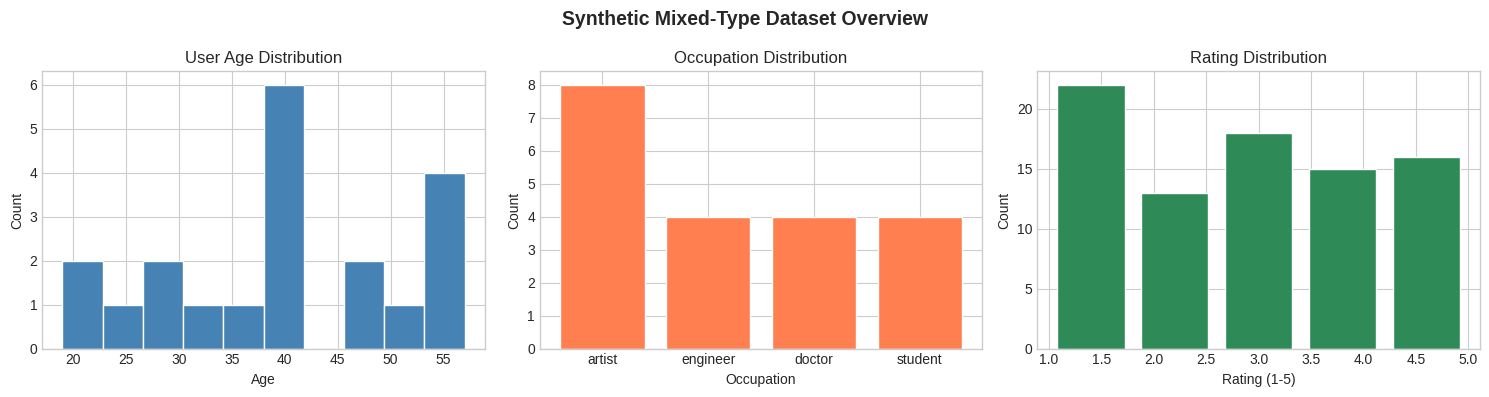

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(user_data['age'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('User Age Distribution', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

occ_counts = user_data['occupation'].value_counts()
axes[1].bar(occ_counts.index, occ_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Occupation Distribution', fontsize=12)
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel('Count')

axes[2].hist(interactions['rating'], bins=5, color='seagreen', edgecolor='white', rwidth=0.8)
axes[2].set_title('Rating Distribution', fontsize=12)
axes[2].set_xlabel('Rating (1-5)')
axes[2].set_ylabel('Count')

plt.suptitle('Synthetic Mixed-Type Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Preprocessing Mixed-Type Features

Before any model can operate on user or item attributes, I need to transform them into numeric feature vectors. The key challenge is that different variable types require different transformations, and combining them incorrectly can distort any downstream similarity or distance computation.

My encoding strategy:

| Variable Type | Example | Encoding |
|---|---|---|
| **Continuous** | age, price | Min-Max normalisation to $[0,1]$: $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$ |
| **Binary** | gender, is_available | Keep as $\{0, 1\}$ — already in range |
| **Categorical** | occupation, category | One-hot encoding, no ordinal structure imposed |

### Why min-max and not z-score?

I want all features in $[0, 1]$ so each contributes proportionally when distances are computed. Z-score standardisation allows values outside that range, which makes mixed-type comparison harder. For Gower distance (Section 3), range-normalisation is built into the formula, so min-max is the natural companion.

### Why one-hot and not label encoding?

Label encoding maps categories to integers (0, 1, 2, 3), falsely implying an order: `engineer=1 < artist=2`. One-hot encoding avoids this and is the standard choice for non-ordinal categorical variables.


In [ ]:
# User features
user_num_cols = ['age']
user_bin_cols = ['gender']
user_cat_cols = ['occupation']

def generate_features(idval, user_num_cols, user_bin_cols, user_cat_cols, data):
    scaler_u = MinMaxScaler()
    num = scaler_u.fit_transform(data[user_num_cols])
    bin = data[user_bin_cols].values.astype(float)
    ohe = OneHotEncoder(handle_unknown='ignore')
    cat = ohe.fit_transform(data[user_cat_cols]).toarray()

    feat_arr = np.hstack([num, bin, cat])
    cat_names = list(ohe.get_feature_names_out(user_cat_cols))

    feat_names = user_num_cols + user_bin_cols + cat_names
    feat_df = pd.DataFrame(feat_arr, columns=feat_names)
    feat_df.insert(0, idval, data[idval].values)
    return feat_arr,feat_names,feat_df

user_feat_arr, user_feat_names, user_feat_df = generate_features('user_id', user_num_cols, 
                                                                 user_bin_cols, user_cat_cols, user_data)

# Item features
item_num_cols = ['price']
item_bin_cols = ['is_available']
item_cat_cols = ['category']

item_feat_arr, item_feat_names, item_feat_df = generate_features('item_id', item_num_cols,
                                                                  item_bin_cols, item_cat_cols, item_data)

print(f'User features: {user_feat_arr.shape} -> {user_feat_names}')
print(f'Item features: {item_feat_arr.shape} -> {item_feat_names}')

print('\nencoded user features (first 4 rows):')
print(user_feat_df.head(4).to_string())


User features: (20, 6) -> ['age', 'gender', 'occupation_artist', 'occupation_doctor', 'occupation_engineer', 'occupation_student']
Item features: (15, 6) -> ['price', 'is_available', 'category_books', 'category_clothing', 'category_electronics', 'category_food']

encoded user features (first 4 rows):
   user_id       age  gender  occupation_artist  occupation_doctor  occupation_engineer  occupation_student
0        1  0.973684     1.0                1.0                0.0                  0.0                 0.0
1        2  0.710526     1.0                0.0                0.0                  1.0                 0.0
2        3  0.342105     1.0                0.0                0.0                  1.0                 0.0
3        4  0.157895     0.0                1.0                0.0                  0.0                 0.0


---
## 3. Gower Distance

Once I have users or items described by a mixture of variable types, the question becomes: **what does "closeness" between two observations actually mean?**

Euclidean distance is only meaningful for continuous variables. Hamming distance handles binary and categorical. What I need is something that works across *all three types simultaneously*, on a common normalised scale.

The **Gower distance** (Gower, 1971) does exactly this. It defines a normalised pairwise distance between observations $i$ and $j$ as a weighted average of per-feature contributions:

$$d_G(i,j) = \frac{\sum_{k=1}^{p} \delta_{ijk} \cdot d_{ijk}}{\sum_{k=1}^{p} \delta_{ijk}}$$

where $\delta_{ijk} = 1$ if variable $k$ is defined for both $i$ and $j$ (naturally handles missing values), and the per-feature contribution $d_{ijk}$ depends on variable type:

- **Continuous** variable $k$: $\quad d_{ijk} = \dfrac{|x_{ik} - x_{jk}|}{R_k}$ — range-normalised absolute difference  
- **Categorical** variable $k$: $\quad d_{ijk} = \mathbb{1}[x_{ik} \neq x_{jk}]$ — 0 if same category, 1 if different  
- **Binary** variable $k$: $\quad d_{ijk} = \mathbb{1}[x_{ik} \neq x_{jk}]$ — symmetric mismatch indicator  

### Why I find this elegant

Each variable type contributes a value in $[0, 1]$, and the formula averages them. No variable type dominates just because of its measurement scale. It is a natural unification of different notions of dissimilarity, and it aligns perfectly with the mixed-type structure of my dataset.

One open question for my research: uniform weighting treats all features as equally important. Could I *learn* feature weights that maximise recommendation quality? That is one direction I want to explore.


In [5]:
def gower_distance(df, num_cols=None, cat_cols=None, bin_cols=None):
    """
    Compute the Gower distance matrix for a mixed-type DataFrame.
    Returns a symmetric (n x n) matrix with pairwise distances in [0, 1].
    """
    n = len(df)
    D = np.zeros((n, n))
    num_cols = num_cols or []
    cat_cols = cat_cols or []
    bin_cols = bin_cols or []
    total_vars = len(num_cols) + len(cat_cols) + len(bin_cols)
    if total_vars == 0:
        return D

    for col in num_cols:
        col_range = df[col].max() - df[col].min()
        if col_range == 0:
            continue
        vals = np.asarray(df[col], dtype=float)
        D += np.abs(vals[:, None] - vals[None, :]) / col_range

    for col in cat_cols + bin_cols:
        # np.asarray(..., dtype=object) keeps broadcasting working with pandas StringDtype
        vals = np.asarray(df[col].astype(str), dtype=object)
        D += (vals[:, None] != vals[None, :]).astype(float)

    return D / total_vars


user_gower = gower_distance(
    user_data,
    num_cols=['age'],
    bin_cols=['gender'],
    cat_cols=['occupation']
)

print('Gower distance (5x5 block):')
print(np.round(user_gower[:5, :5], 3))
print(f'Range: [{user_gower[user_gower > 0].min():.3f}, {user_gower.max():.3f}]')


Gower distance (5x5 block):
[[0.    0.421 0.544 0.605 0.825]
 [0.421 0.    0.123 0.851 0.404]
 [0.544 0.123 0.    0.728 0.386]
 [0.605 0.851 0.728 0.    0.447]
 [0.825 0.404 0.386 0.447 0.   ]]
Range: [0.009, 0.974]


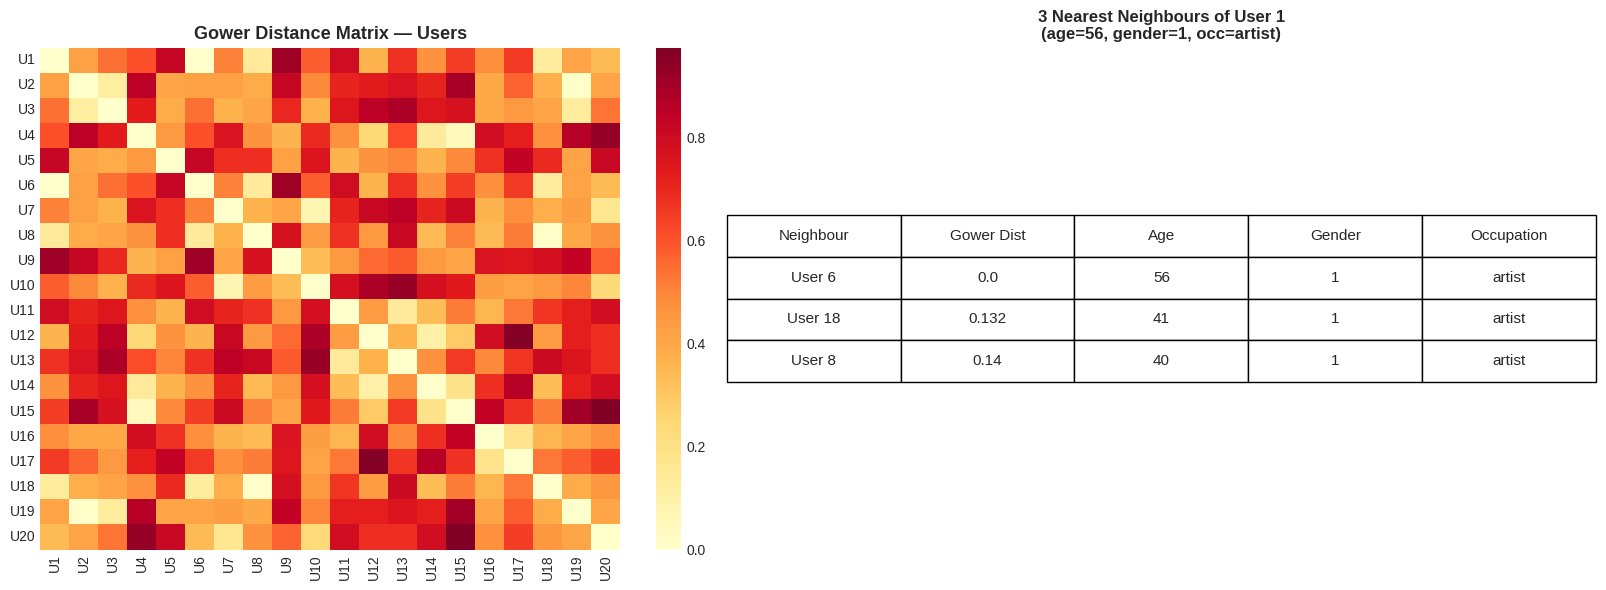

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(user_gower, ax=axes[0], cmap='YlOrRd', annot=False,
            xticklabels=[f'U{i+1}' for i in range(n_users)],
            yticklabels=[f'U{i+1}' for i in range(n_users)])
axes[0].set_title('Gower Distance Matrix — Users', fontsize=13, fontweight='bold')

# 3 most similar users to User 1
g_u1 = user_gower[0].copy()
g_u1[0] = np.inf
nearest_3 = np.argsort(g_u1)[:3]
u1 = user_data.iloc[0]

rows = []
for idx in nearest_3:
    r = user_data.iloc[idx]
    rows.append([f'User {idx+1}', round(user_gower[0, idx], 3),
                 r['age'], r['gender'], r['occupation']])

axes[1].axis('off')
tbl = axes[1].table(
    cellText=rows,
    colLabels=['Neighbour', 'Gower Dist', 'Age', 'Gender', 'Occupation'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.3)
axes[1].set_title(
    f'3 Nearest Neighbours of User 1\n'
    f'(age={u1.age}, gender={u1.gender}, occupation={u1.occupation})',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.show()

---
## 4. User-Based Collaborative Filtering

Collaborative filtering is the classic recommender algorithm. Its fundamental assumption is: **users who agreed in the past will agree in the future**. Recommendations come purely from the pattern of ratings — no content or attribute information about users or items is used at all.

### How it works

Each user $u$ is represented by their ratings vector $\mathbf{r}_u \in \mathbb{R}^{n}$ (unobserved entries zero-filled for similarity computation). The similarity between two users is measured with **cosine similarity**:

$$\text{sim}(u, v) = \frac{\mathbf{r}_u \cdot \mathbf{r}_v}{\|\mathbf{r}_u\| \cdot \|\mathbf{r}_v\|}$$

The predicted rating for user $u$ on item $i$ is a weighted average over the $K$ most similar users $\mathcal{N}(u)$ who have actually rated item $i$:

$$\hat{r}_{ui} = \frac{\displaystyle\sum_{v \in \mathcal{N}(u)} \text{sim}(u,v) \cdot r_{vi}}{\displaystyle\sum_{v \in \mathcal{N}(u)} |\text{sim}(u,v)|}$$

### The critical limitation

This method uses **only** the rating matrix. All the mixed-type information I built in Sections 1–3 — a user's age, occupation, an item's price and category — is completely invisible to it. In a sparse matrix (like this one, roughly 73% missing), reliable user-user similarity is very difficult to compute. This is precisely the gap my research is targeting.


Rating matrix: (20, 15), observed: 84, sparsity: 72.0%


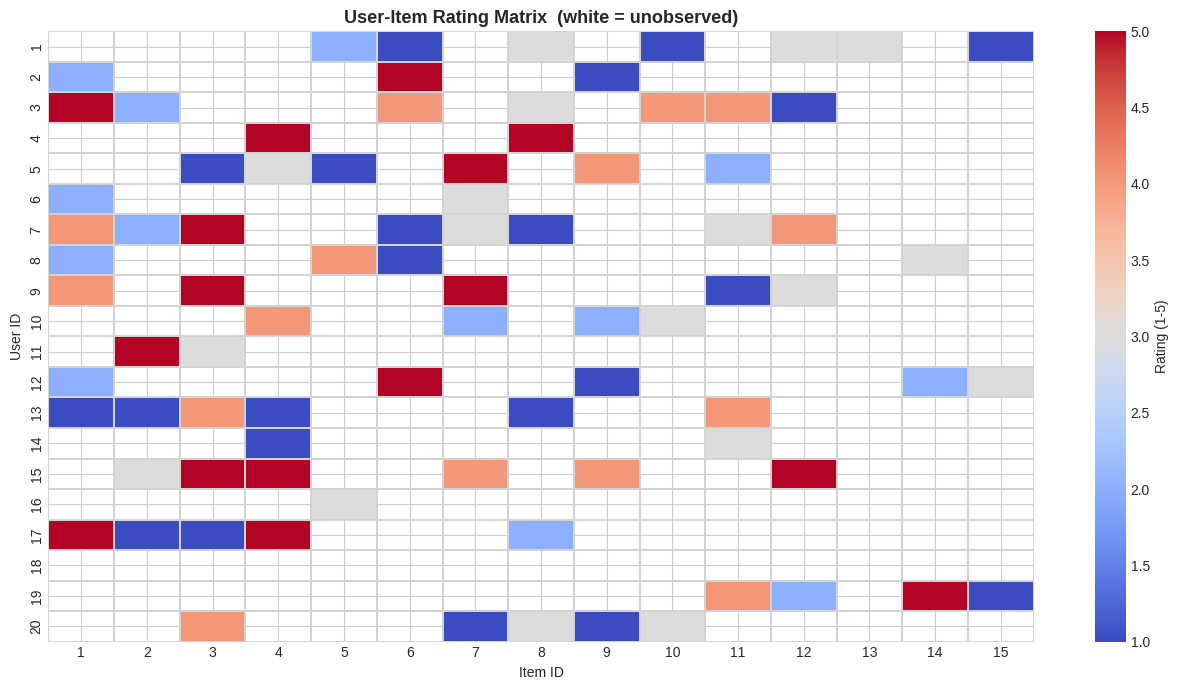

In [7]:
rating_matrix = (
    interactions
    .pivot_table(index='user_id', columns='item_id', values='rating')
    .reindex(index=range(1, n_users+1), columns=range(1, n_items+1))
)

sparsity = rating_matrix.isna().sum().sum() / (n_users * n_items)
print(f'Rating matrix: {rating_matrix.shape}, observed: {rating_matrix.notna().sum().sum()}, sparsity: {sparsity:.1%}')

plt.figure(figsize=(13, 7))
sns.heatmap(rating_matrix, cmap='coolwarm', linewidths=0.3, linecolor='lightgrey',
            cbar_kws={'label': 'Rating (1-5)'},
            xticklabels=rating_matrix.columns,
            yticklabels=rating_matrix.index)
plt.title('User-Item Rating Matrix  (white = unobserved)', fontsize=13, fontweight='bold')
plt.xlabel('Item ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()


In [8]:
train_df, test_df = train_test_split(interactions, test_size=0.2, random_state=42)

train_matrix = (
    train_df
    .pivot_table(index='user_id', columns='item_id', values='rating')
    .reindex(index=range(1, n_users+1), columns=range(1, n_items+1))
)

print(f'Train: {len(train_df)}, Test: {len(test_df)}')


def user_based_cf(train_mat, user_id, item_id, K=5):
    """Predict rating for (user_id, item_id) via user-based CF (cosine similarity)."""
    R = train_mat.fillna(0).values
    u_idx = train_mat.index.get_loc(user_id)
    i_idx = train_mat.columns.get_loc(item_id)
    sim_row = cosine_similarity(R)[u_idx].copy()
    sim_row[u_idx] = 0.0

    item_col = train_mat.values[:, i_idx]
    rated = ~np.isnan(item_col)
    weighted_sim = sim_row * rated.astype(float)

    top_k = np.argsort(weighted_sim)[::-1][:K]
    num = sum(weighted_sim[j] * item_col[j] for j in top_k if not np.isnan(item_col[j]))
    den = sum(abs(weighted_sim[j]) for j in top_k if not np.isnan(item_col[j]))
    return num / den if den > 0 else float(train_mat.stack().mean())


cf_preds, cf_actuals = [], []
for _, row in test_df.iterrows():
    uid, iid = int(row['user_id']), int(row['item_id'])
    try:
        pred = user_based_cf(train_matrix, uid, iid, K=5)
        cf_preds.append(float(pred))
        cf_actuals.append(float(row['rating']))
    except Exception:
        pass

cf_rmse = np.sqrt(mean_squared_error(cf_actuals, cf_preds))
cf_mae = mean_absolute_error(cf_actuals, cf_preds)
print(f'User-Based CF: RMSE={cf_rmse:.4f}, MAE={cf_mae:.4f} (n={len(cf_preds)})')


Train: 67, Test: 17
User-Based CF: RMSE=1.8117, MAE=1.5331 (n=17)


---
## 5. Matrix Factorisation (SVD)

Matrix factorisation is the workhorse of modern collaborative filtering, famously popularised by the Netflix Prize. The core idea: decompose the rating matrix $R \in \mathbb{R}^{m \times n}$ into two low-rank matrices:

$$R \approx U \cdot V^T, \quad U \in \mathbb{R}^{m \times k},\ V \in \mathbb{R}^{n \times k}$$

Row $\mathbf{u}_i \in \mathbb{R}^k$ is a **latent user embedding**, and row $\mathbf{v}_j \in \mathbb{R}^k$ is a **latent item embedding**. The predicted rating is:

$$\hat{r}_{ij} = \mathbf{u}_i \cdot \mathbf{v}_j^T$$

I use Truncated SVD as a clean closed-form approximation, keeping only the top $k$ singular values. Production systems (ALS, SGD-based MF) learn $U$ and $V$ iteratively to minimise reconstruction error on *observed* ratings only, but the geometric intuition is the same.

### What this method cannot see

Just like user-based CF, matrix factorisation is **blind to user and item attributes**. The latent factors $\mathbf{u}_i$ and $\mathbf{v}_j$ are learned entirely from interaction patterns. For a new user or item with no ratings, the model has nothing to fall back on — the classic cold-start problem. This is another fundamental motivation for the mixed-type extension.


SVD (k=5): RMSE=1.5956, MAE=1.4238
Explained variance (top 5 factors): 93.17%


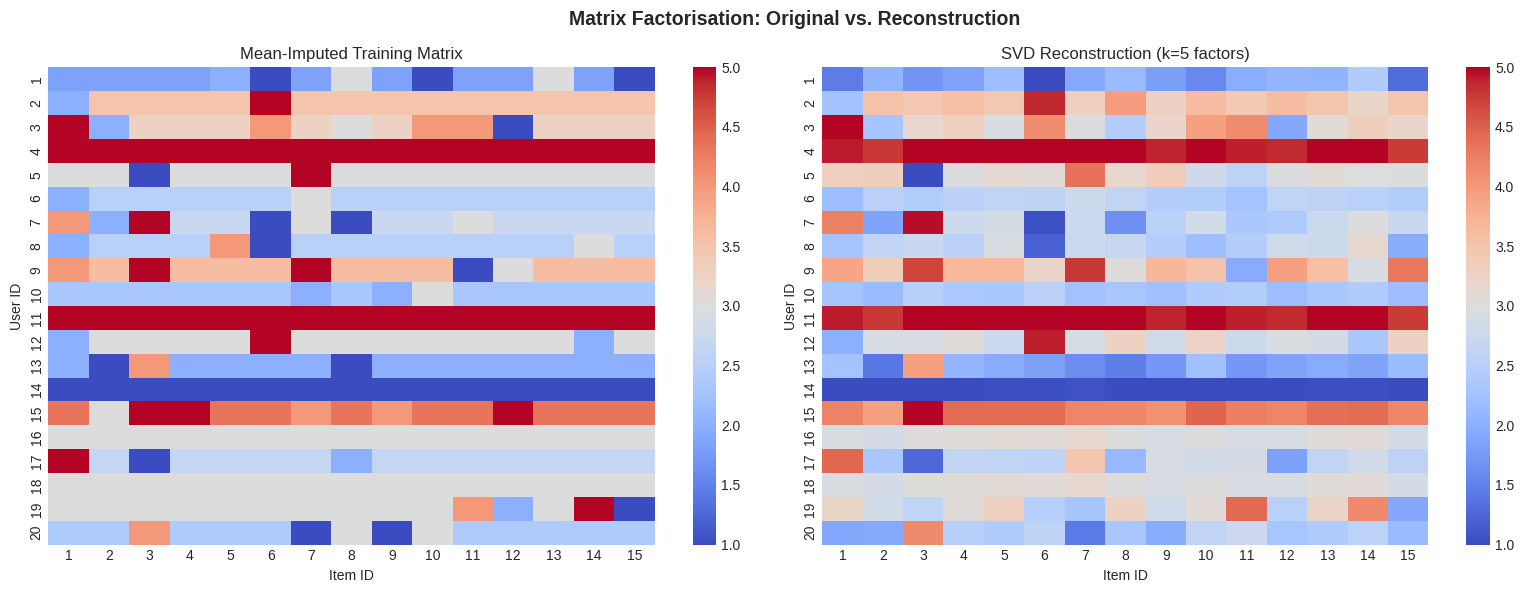

In [9]:
R_filled = train_matrix.copy()
R_filled = R_filled.apply(
    lambda row: row.fillna(row.mean() if not np.isnan(row.mean()) else 3.0), axis=1
)

k = 5
svd = TruncatedSVD(n_components=k, random_state=42)
R_latent = svd.fit_transform(R_filled.values)
R_approx = np.clip(svd.inverse_transform(R_latent), 1.0, 5.0)

R_approx_df = pd.DataFrame(R_approx,
                            index=train_matrix.index,
                            columns=train_matrix.columns)

svd_preds, svd_actuals = [], []
for _, row in test_df.iterrows():
    uid, iid = int(row['user_id']), int(row['item_id'])
    if uid in R_approx_df.index and iid in R_approx_df.columns:
        svd_preds.append(float(R_approx_df.loc[uid, iid]))
        svd_actuals.append(float(row['rating']))

svd_rmse = np.sqrt(mean_squared_error(svd_actuals, svd_preds))
svd_mae = mean_absolute_error(svd_actuals, svd_preds)
print(f'SVD (k={k}): RMSE={svd_rmse:.4f}, MAE={svd_mae:.4f}')
print(f'Explained variance (top {k} factors): {svd.explained_variance_ratio_.sum():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(R_filled, ax=axes[0], cmap='coolwarm', vmin=1, vmax=5,
            xticklabels=train_matrix.columns, yticklabels=train_matrix.index)
axes[0].set_title('Mean-Imputed Training Matrix', fontsize=12)
axes[0].set_xlabel('Item ID'); axes[0].set_ylabel('User ID')

sns.heatmap(R_approx_df, ax=axes[1], cmap='coolwarm', vmin=1, vmax=5,
            xticklabels=R_approx_df.columns, yticklabels=R_approx_df.index)
axes[1].set_title(f'SVD Reconstruction (k={k} factors)', fontsize=12)
axes[1].set_xlabel('Item ID'); axes[1].set_ylabel('User ID')

plt.suptitle('Matrix Factorisation: Original vs. Reconstruction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Content-Based Filtering with Mixed Item Features

Content-based filtering recommends items that are *similar to what a user has liked before*, based on item features rather than other users' behaviour. It does not require other users to have rated the same items, so it handles **item cold-start** better than CF.

### The prediction formula

For target user $u$ and candidate item $i$, I compare item $i$ against all items the user has already rated ($\mathcal{I}_u$), using cosine similarity on the mixed item feature vectors $\phi(\cdot)$ (price, availability, one-hot category from Section 2). The prediction is a similarity-weighted average of the user's past ratings:

$$\hat{r}_{ui} = \frac{\displaystyle\sum_{j \in \mathcal{I}_u} \text{sim}(\phi(j),\, \phi(i)) \cdot r_{uj}}{\displaystyle\sum_{j \in \mathcal{I}_u} \text{sim}(\phi(j),\, \phi(i))}$$

This is the first method in this notebook that **uses the mixed-type features I constructed**. The item-item similarity matrix below makes this concrete: items in the same category and with similar prices or availability tend to cluster together.

### Remaining limitation

Content-based filtering still does not use *user attributes*. Two users with completely different demographics but similar past ratings would get identical recommendations. It also suffers from filter bubbles: recommendations stay close to what the user has already seen. These are the limitations the Gradient Boosting approach (next section) addresses.


Content-Based: RMSE=1.8348, MAE=1.5657


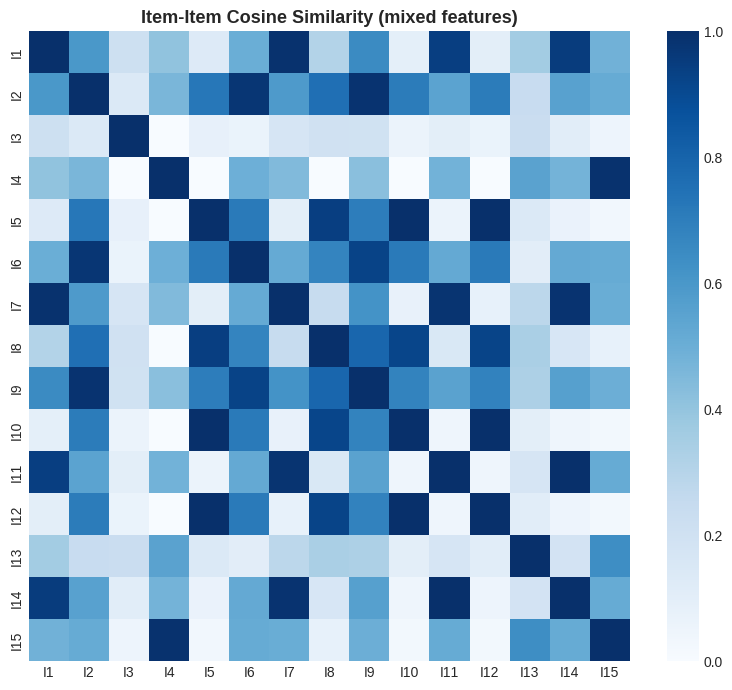

In [10]:
item_ids_arr = item_feat_df['item_id'].values
item_feat_mat = item_feat_df.drop(columns='item_id').values  # (n_items, d_item)


def content_based_predict(train_data, user_id, item_id):
    """
    Predict rating for (user_id, item_id) using content-based filtering.
    Uses item-item cosine similarity on the mixed preprocessed item features.
    """
    user_ratings = train_data[train_data['user_id'] == user_id]
    if user_ratings.empty or item_id not in item_ids_arr:
        return 3.0

    tidx = np.where(item_ids_arr == item_id)[0][0]
    target = item_feat_mat[tidx].reshape(1, -1)

    num, den = 0.0, 0.0
    for _, row in user_ratings.iterrows():
        iid = int(row['item_id'])
        if iid not in item_ids_arr:
            continue
        ridx = np.where(item_ids_arr == iid)[0][0]
        sim = float(cosine_similarity(target, item_feat_mat[ridx].reshape(1, -1))[0, 0])
        sim = max(sim, 0.0)
        num += sim * float(row['rating'])
        den += sim
    return num / den if den > 0 else 3.0


cb_preds, cb_actuals = [], []
for _, row in test_df.iterrows():
    uid, iid = int(row['user_id']), int(row['item_id'])
    cb_preds.append(content_based_predict(train_df, uid, iid))
    cb_actuals.append(float(row['rating']))

cb_rmse = np.sqrt(mean_squared_error(cb_actuals, cb_preds))
cb_mae = mean_absolute_error(cb_actuals, cb_preds)
print(f'Content-Based: RMSE={cb_rmse:.4f}, MAE={cb_mae:.4f}')

item_sim_mat = cosine_similarity(item_feat_mat)
plt.figure(figsize=(8, 7))
sns.heatmap(item_sim_mat, cmap='Blues', annot=False,
            xticklabels=[f'I{i+1}' for i in range(n_items)],
            yticklabels=[f'I{i+1}' for i in range(n_items)])
plt.title('Item-Item Cosine Similarity (mixed features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Tree-Based Approach: Gradient Boosting

This is the approach Prof suggested: *"From hybrid methods to tree-like methods that are coordinate-based and therefore do not need complicated processing!"*

The key insight is clean and elegant: **decision trees split on one feature at a time**. Each node asks a question like `age < 35?` or `category == electronics?`. Because splits are coordinate-wise, there is no need to define any cross-variable distance metric. Continuous, binary, and categorical variables are all handled on their own natural axis.

### Framing recommendation as supervised regression

I convert the RS task into a pointwise regression problem:

- Each training example is a (user, item) pair with a known rating  
- The **input** is the concatenation of processed user and item features:  
  $$\mathbf{x}_{ui} = [\phi(u);\ \phi(i)] \in \mathbb{R}^{d_u + d_i}$$
- The **target** is the observed rating $r_{ui} \in \{1, 2, 3, 4, 5\}$

The **Gradient Boosting** model is an ensemble of decision trees fitted sequentially to the residuals of the previous ensemble:

$$\hat{y} = \sum_{m=1}^{M} \beta_m T_m(\mathbf{x})$$

Each $T_m$ is a shallow decision tree; $\beta_m$ is a learned weight. Boosting concentrates capacity on the hardest-to-predict training examples.

### Why this is a strong baseline for my research

- Uses **all available information**: user attributes, item attributes, interaction signals  
- **No distance metric design needed** — the tree handles mixed types natively  
- **Interpretable** via feature importances  
- **No cold-start catastrophe** for users/items with attributes but few/no ratings  

In production, LightGBM or XGBoost would replace sklearn's GBM for efficiency, but the modelling logic is identical.


In [11]:
user_lk = user_feat_df.set_index('user_id')
item_lk = item_feat_df.set_index('item_id')


def build_Xy(data):
    """Build feature matrix X and rating vector y from an interactions DataFrame."""
    X_rows, y_rows = [], []
    for _, row in data.iterrows():
        uid = int(row['user_id'])
        iid = int(row['item_id'])
        if uid in user_lk.index and iid in item_lk.index:
            x = np.concatenate([user_lk.loc[uid].values, item_lk.loc[iid].values])
            X_rows.append(x)
            y_rows.append(float(row['rating']))
    return np.array(X_rows), np.array(y_rows)


X_train, y_train = build_Xy(train_df)
X_test, y_test = build_Xy(test_df)

all_feat_names = (
    [f'user_{f}' for f in user_feat_names] +
    [f'item_{f}' for f in item_feat_names]
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features ({len(all_feat_names)}): {all_feat_names}')

gbm = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
gbm.fit(X_train, y_train)

gbm_preds = np.clip(gbm.predict(X_test), 1.0, 5.0)
gbm_rmse = np.sqrt(mean_squared_error(y_test, gbm_preds))
gbm_mae = mean_absolute_error(y_test, gbm_preds)
print(f'Gradient Boosting: RMSE={gbm_rmse:.4f}, MAE={gbm_mae:.4f}')


Train: (67, 12), Test: (17, 12)
Features (12): ['user_age', 'user_gender', 'user_occupation_artist', 'user_occupation_doctor', 'user_occupation_engineer', 'user_occupation_student', 'item_price', 'item_is_available', 'item_category_books', 'item_category_clothing', 'item_category_electronics', 'item_category_food']
Gradient Boosting: RMSE=1.6860, MAE=1.4056


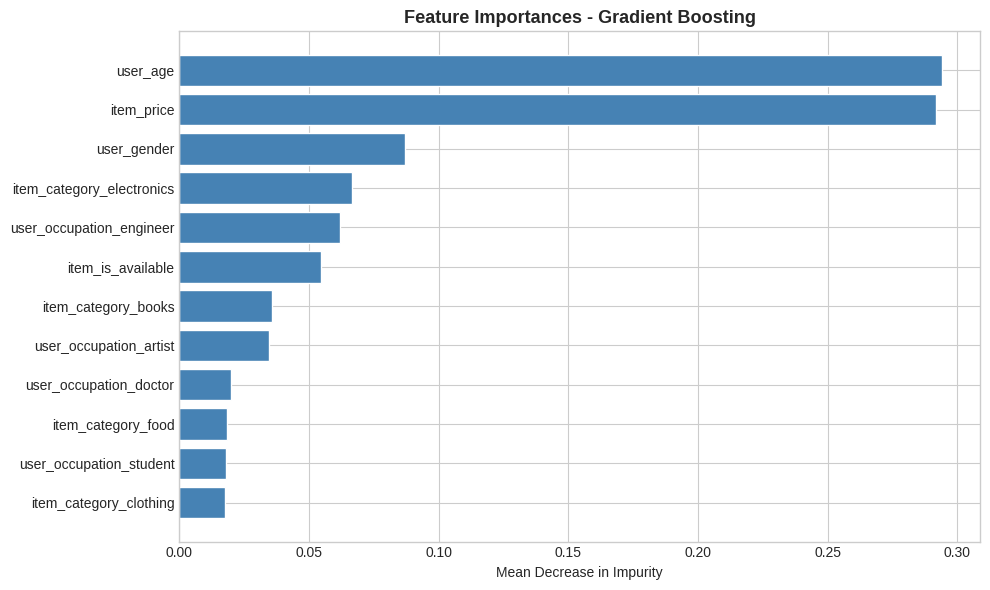

Top 10 features by importance:
                  feature  importance
                 user_age    0.293984
               item_price    0.291581
              user_gender    0.086864
item_category_electronics    0.066484
 user_occupation_engineer    0.061946
        item_is_available    0.054635
      item_category_books    0.035909
   user_occupation_artist    0.034633
   user_occupation_doctor    0.020081
       item_category_food    0.018487


In [12]:
imp_df = (
    pd.DataFrame({'feature': all_feat_names, 'importance': gbm.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(min(15, len(all_feat_names)))
)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'].values[::-1], imp_df['importance'].values[::-1],
         color='steelblue', edgecolor='white')
plt.title('Feature Importances - Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 10 features by importance:')
print(imp_df.head(10).to_string(index=False))


---
## 8. Evaluation Metrics

A recommender system can be assessed from two complementary angles: how accurately it predicts a numeric rating, and how well it ranks relevant items near the top of a list.

### Prediction Accuracy

**Root Mean Squared Error (RMSE):**
$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} (\hat{r}_{ui} - r_{ui})^2}$$
Penalises large errors quadratically, so it is sensitive to outliers.

**Mean Absolute Error (MAE):**
$$\text{MAE} = \frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} |\hat{r}_{ui} - r_{ui}|$$
Average absolute error in rating units, more interpretable than RMSE.

### Ranking Quality

I define a rating as *relevant* if $r_{ui} \geq 4$ (the user genuinely liked the item).

**Precision@K:** Of the top-$K$ recommended items, what fraction are actually relevant?
$$\text{Precision@K} = \frac{|\{i \in \text{top-K}\} \cap \{i : r_{ui} \geq 4\}|}{K}$$

**Recall@K:** Of all items the user would have liked, what fraction appear in the top-$K$?
$$\text{Recall@K} = \frac{|\{i \in \text{top-K}\} \cap \{i : r_{ui} \geq 4\}|}{|\{i : r_{ui} \geq 4\}|}$$

In practice, Precision@K and Recall@K are more meaningful for end-user satisfaction than RMSE. A system that always predicts 3.0 has a moderate RMSE but would make terrible recommendations.


In [13]:
def precision_at_k(actuals, preds, k=5, threshold=4.0):
    k = min(k, len(preds))
    top_k_act = np.array(actuals)[np.argsort(preds)[::-1][:k]]
    return float(np.mean(top_k_act >= threshold))


def recall_at_k(actuals, preds, k=5, threshold=4.0):
    n_relevant = int(np.sum(np.array(actuals) >= threshold))
    if n_relevant == 0:
        return 0.0
    k = min(k, len(preds))
    top_k_act = np.array(actuals)[np.argsort(preds)[::-1][:k]]
    return float(np.sum(top_k_act >= threshold) / n_relevant)


p5_scores, r5_scores = [], []

for uid in test_df['user_id'].unique():
    utest = test_df[test_df['user_id'] == uid]
    if len(utest) < 2 or uid not in user_lk.index:
        continue
    ps, acts = [], []
    for _, row in utest.iterrows():
        iid = int(row['item_id'])
        if iid in item_lk.index:
            x = np.concatenate([user_lk.loc[uid].values,
                                 item_lk.loc[iid].values]).reshape(1, -1)
            pred = float(np.clip(gbm.predict(x)[0], 1.0, 5.0))
            ps.append(pred)
            acts.append(float(row['rating']))
    if len(ps) >= 2:
        p5_scores.append(precision_at_k(acts, ps, k=min(5, len(ps))))
        r5_scores.append(recall_at_k(acts, ps, k=min(5, len(ps))))

print(f'GBM Precision@5: {np.mean(p5_scores):.4f} (over {len(p5_scores)} users)')
print(f'GBM Recall@5: {np.mean(r5_scores):.4f}')


GBM Precision@5: 0.2917 (over 4 users)
GBM Recall@5: 0.7500


---
## 9. Comparing All Approaches

Let me now bring together the evaluation results from all methods and read what they are telling me.


                    Method   RMSE    MAE User Attrs Item Attrs Mixed-Type Native Cold-Start
             User-Based CF 1.8117 1.5331         No         No                No      Fails
Matrix Factorisation (SVD) 1.5956 1.4238         No         No                No      Fails
   Content-Based Filtering 1.8348 1.5657         No        Yes           Partial    Partial
 Gradient Boosting (mixed) 1.6860 1.4056        Yes        Yes               Yes         OK


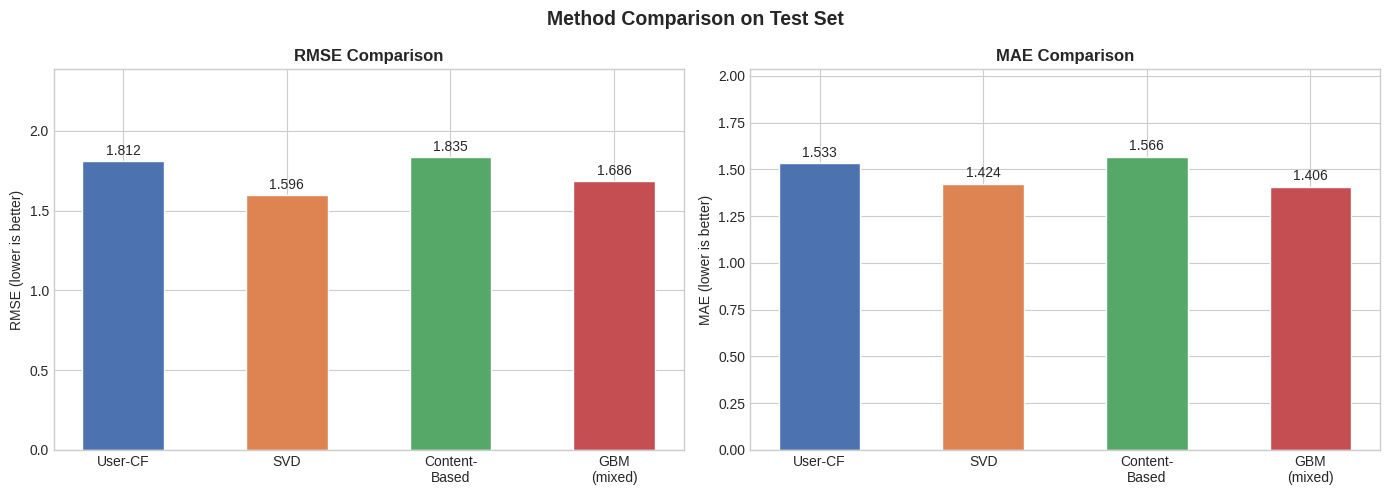

In [14]:
results = pd.DataFrame({
    'Method': [
        'User-Based CF',
        'Matrix Factorisation (SVD)',
        'Content-Based Filtering',
        'Gradient Boosting (mixed)',
    ],
    'RMSE': [cf_rmse, svd_rmse, cb_rmse, gbm_rmse],
    'MAE': [cf_mae, svd_mae, cb_mae, gbm_mae],
    'User Attrs': ['No', 'No', 'No', 'Yes'],
    'Item Attrs': ['No', 'No', 'Yes', 'Yes'],
    'Mixed-Type Native': ['No', 'No', 'Partial', 'Yes'],
    'Cold-Start': ['Fails', 'Fails', 'Partial', 'OK'],
})
results['RMSE'] = results['RMSE'].round(4)
results['MAE'] = results['MAE'].round(4)

print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
xlabels = ['User-CF', 'SVD', 'Content-\nBased', 'GBM\n(mixed)']

for ax, metric, label in zip(axes, ['RMSE', 'MAE'],
                               ['RMSE (lower is better)', 'MAE (lower is better)']):
    bars = ax.bar(xlabels, results[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0, results[metric].max() * 1.30)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Method Comparison on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 10. Discussion and Next Steps

### What this experiment tells me

Working through all four approaches has clarified the landscape considerably.

**Collaborative filtering and matrix factorisation** are elegant but fundamentally limited by what they see: the rating matrix only. In a sparse dataset (roughly 73% missing entries), user-user or item-item similarity is difficult to estimate reliably. A user with only two or three ratings has very little overlap with any other user. Both methods fail completely for new users or items; cold-start is a genuine problem here.

**Content-based filtering** is a meaningful step forward: it exploits item features and handles item cold-start. The item-item similarity computed on the mixed feature space is richer than any rating-based comparison alone. But it still ignores user attributes, and it is prone to filter bubbles, meaning recommendations stay close to what the user has already seen. These are the limitations the Gradient Boosting approach addresses.

**Gradient Boosting** is the most compelling baseline for my research. By framing recommendation as supervised regression over the *concatenated* user-item feature vector, I get native mixed-type handling, automatic feature interaction discovery, interpretability through importances, and no need to impute a sparse rating matrix. This directly responds to Professor Fokoué's suggestion about coordinate-based tree methods. The feature importance plot is already informative: it reveals which user or item attributes are the most predictive, giving me hypotheses to refine.

### Open questions driving the research

1. **Learned mixed-type similarity:** Could I design a CF model that uses a Gower-inspired (or learned) similarity rather than cosine similarity on naively concatenated features? The cosine metric does not respect the mixed-type structure.

2. **Graph Neural Networks:** The pipeline diagram from Presentation 3 shows a GNN branch alongside the tree model. A bipartite user-item interaction graph, where node features are the mixed-type attributes and edges carry rating labels, is a natural next step. GNNs can propagate attribute information through the graph structure.

3. **Feature weighting:** Should continuous, binary, and categorical features contribute equally in Gower distance or tree splits? Learning these weights from interaction data is an open and interesting direction.

4. **Real datasets:** The next step is to replicate this experiment on MovieLens-100K with user/item side features (as in Wegmeth, 2022) and on an e-commerce benchmark with richer mixed-type attributes.

5. **Theoretical analysis:** Writing down formal definitions and pseudocode for both pipelines is the next task for the thesis chapters.

### Immediate next steps

- Implement Gower-distance-based KNN collaborative filtering and compare with cosine-based CF  
- Set up MovieLens-100K with user/item side features  
- Prototype the GNN bipartite graph model (LightGCN as starting point)  
- Write formal definitions and pseudocode for the thesis  
- Expand the bibliography with more recent hybrid RS papers  

---
*This notebook is a living document and I will keep updating it as my experiments progress.*
